<a href="https://colab.research.google.com/github/carolsworld/NX_TSC/blob/main/OPCUANetwork_IsolationForest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Demonstration of using network packet files generated during the NX MCD simulation for developing Unsupervised Learning Model for Threat Detection using IsolationForest in sklearn library. The goal of this task is to identify behaviours related to writing commands to PLC for anomaly scoring.  

#Background

We have identified 6 different scenarios in the NX scene. It could be a normal scenarios or threat scenarios. For each scenario, we have carried out 10 simulation runs (i.e. 10 instances). Therefore, there are tototally 60 simulation instances in the csv dataset. Each simulation run has 60 second of simulation. Instance 1 to 10 are normal operation for baseline without intervention. Instance 11 to 60 are threat scenario, such as issuing write request from OPC UA Client via HMI or UA Expert.

During the simulation run, we used Wireshark to collect network packet data between the OPC UA Server and OPC UA Client. Each packet contains roughly 1 minute of simulation. The packet capture (.pcapng) is analysed using Zeek with OPC UA Plug-in. The output file named 'opcua_binary.log' for each instance is used for model training and testing.

The goal of using unsupervised learning (IsolationForest) to identify write behaviours for anomaly scoring.  

#Step 0 - Check GPU

In [1]:
# Turn on GPU T4

# Runtime > Change runtime type

gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Tue Apr 15 13:21:44 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   61C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

#Step 1 - File upload

In [2]:
# Upload csv file and check the number of rows and columns in the pandas dataframe
from google.colab import files
import io
import pandas as pd

uploaded = files.upload()

filename = next(iter(uploaded))

df = pd.read_csv(io.BytesIO(uploaded['opcua_instance1-60_sliced_1min.csv']))

print("The number of rows and columns in the csv file: ", df.shape)

Saving opcua_instance1-60_sliced_1min.csv to opcua_instance1-60_sliced_1min.csv
The number of rows and columns in the csv file:  (143532, 12)


60 instances with varied number of rows for each instance, expected number of row is 143,532.

In [3]:
# Display the first few rows of the dataframe to check file format
df.head()

,instance,ts,uid,id.orig_h,id.orig_p,id.resp_h,id.resp_p,is_orig,opcua_link_id,is_final,msg_size,identifier
0,11,2025-04-04 07:58:18.703329086,CzqpnW2lgtoYqfzBX3,10.12.25.3,58483,10.12.25.30,4840,T,b24823c38f8b391058,F,253,673.0
1,11,2025-04-04 07:58:18.704535961,CzqpnW2lgtoYqfzBX3,10.12.25.3,58483,10.12.25.30,4840,F,362ff5e106a1dd4a53,F,100,676.0
2,11,2025-04-04 07:58:18.709357977,CzqpnW2lgtoYqfzBX3,10.12.25.3,58483,10.12.25.30,4840,T,09ab50f6e61b17f8ed,F,204,631.0
3,11,2025-04-04 07:58:18.713709116,CzqpnW2lgtoYqfzBX3,10.12.25.3,58483,10.12.25.30,4840,F,13f0d417ec669f7ba7,F,189,634.0
4,11,2025-04-04 07:58:18.823952913,CzqpnW2lgtoYqfzBX3,10.12.25.3,58483,10.12.25.30,4840,T,7254425bfcbe419d9c,F,253,673.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143532 entries, 0 to 143531
Data columns (total 12 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   instance       143532 non-null  int64  
 1   ts             143532 non-null  object 
 2   uid            143532 non-null  object 
 3   id.orig_h      143532 non-null  object 
 4   id.orig_p      143532 non-null  int64  
 5   id.resp_h      143532 non-null  object 
 6   id.resp_p      143532 non-null  int64  
 7   is_orig        143532 non-null  object 
 8   opcua_link_id  143532 non-null  object 
 9   is_final       143532 non-null  object 
 10  msg_size       143532 non-null  int64  
 11  identifier     143532 non-null  float64
dtypes: float64(1), int64(4), object(7)
memory usage: 13.1+ MB


# Step 2 - Dataset preprocessing and feature extraction for instance-level anomaly detection (1 minute per instance)

In [5]:
# Timestamp
df['ts'] = pd.to_datetime(df['ts'], errors='coerce')

# Use source port to distinguish between HMI, UA Expert or PLC (automated activity)
df['id.orig_p'] = pd.to_numeric(df['id.orig_p'], errors='coerce')

#  Binary encode for message initiator (OPC UA client / message request = 1; OPC UA server / message responder = 0)
if df['is_orig'].dtype == 'object':
    df['is_orig'] = df['is_orig'].astype(str).str.strip().str.upper().map({'T': 1, 'F': 0})

#  Binary encode for message status (Complete message = 1; Incomplete message = 0)
if df['is_final'].dtype == 'object':
    df['is_final'] = df['is_final'].astype(str).str.strip().str.upper().map({'T': 1, 'F': 0})

In [6]:
# Convert identifier to numeric, drop invalid rows
df = df[df['identifier'] != '-'].copy()
df['identifier'] = pd.to_numeric(df['identifier'], errors='coerce')
df.dropna(subset=['identifier'], inplace=True)
df['identifier'] = df['identifier'].astype('Int64')

# Ensure msg_size is numeric
df['msg_size'] = pd.to_numeric(df['msg_size'], errors='coerce')

In [7]:
# Create semantic flag for write operations
df['is_WriteOps'] = (df['identifier'] == 673).astype(int)

# Define most common message size used for write ops
common_write_size = df[df['identifier'] == 673]['msg_size'].mode().iloc[0]

# Binary flag for anomalies in write operation size
df['write_msg_anomaly'] = ((df['identifier'] == 673) & (df['msg_size'] != common_write_size)).astype(int)

In [8]:
# Aggregate features for each instance
instance_summary = df.groupby('instance').agg({
    'write_msg_anomaly': ['sum', 'mean'],
    'is_WriteOps': ['sum', 'mean'],
    'msg_size': 'count'
})

# Flatten column names
instance_summary.columns = ['_'.join(col).strip() for col in instance_summary.columns]
instance_summary = instance_summary.rename(columns={
    'write_msg_anomaly_sum': 'write_anomaly_count',
    'write_msg_anomaly_mean': 'write_anomaly_ratio',
    'is_WriteOps_sum': 'write_ops_count',
    'is_WriteOps_mean': 'write_ops_ratio',
    'msg_size_count': 'total_packets'
}).reset_index()

In [9]:
# Display the first few rows of the dataframe to check file format
instance_summary.head()

,instance,write_anomaly_count,write_anomaly_ratio,write_ops_count,write_ops_ratio,total_packets
0,1,0,0.0,584,0.234256,2493
1,2,0,0.0,514,0.233424,2202
2,3,0,0.0,583,0.234231,2489
3,4,0,0.0,572,0.234234,2442
4,5,0,0.0,540,0.234070,2307


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143532 entries, 0 to 143531
Data columns (total 14 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   instance           143532 non-null  int64         
 1   ts                 143532 non-null  datetime64[ns]
 2   uid                143532 non-null  object        
 3   id.orig_h          143532 non-null  object        
 4   id.orig_p          143532 non-null  int64         
 5   id.resp_h          143532 non-null  object        
 6   id.resp_p          143532 non-null  int64         
 7   is_orig            143532 non-null  int64         
 8   opcua_link_id      143532 non-null  object        
 9   is_final           143532 non-null  int64         
 10  msg_size           143532 non-null  int64         
 11  identifier         143532 non-null  Int64         
 12  is_WriteOps        143532 non-null  int64         
 13  write_msg_anomaly  143532 non-null  int64   

# Step 3 - IsolationForest

In [11]:
# Features to use
features_for_iforest = ['write_anomaly_count', 'write_anomaly_ratio', 'write_ops_ratio']

In [12]:
# Use normal instances 1–10 to fit baseline
X_train = instance_summary[instance_summary['instance'] <= 10][features_for_iforest]
X_all = instance_summary[features_for_iforest]

In [13]:
# Fit the model
from sklearn.ensemble import IsolationForest

iso_015 = IsolationForest(n_estimators=100, contamination=0.15, random_state=42)
iso_02 = IsolationForest(n_estimators=100, contamination=0.2, random_state=42)
iso_025 = IsolationForest(n_estimators=100, contamination=0.25, random_state=42)
iso_03 = IsolationForest(n_estimators=100, contamination=0.3, random_state=42)
iso_035 = IsolationForest(n_estimators=100, contamination=0.35, random_state=42)

iso_015.fit(X_train)
iso_02.fit(X_train)
iso_025.fit(X_train)
iso_03.fit(X_train)
iso_035.fit(X_train)

IsolationForest(contamination=0.35, random_state=42)

In [14]:
# Predict anomaly scores
instance_summary['anomaly_score_0.15'] = iso_015.decision_function(X_all)
instance_summary['anomaly_0.15'] = iso_015.predict(X_all)  # -1 = anomaly

instance_summary['anomaly_score_0.2'] = iso_02.decision_function(X_all)
instance_summary['anomaly_0.2'] = iso_02.predict(X_all)  # -1 = anomaly

instance_summary['anomaly_score_0.25'] = iso_025.decision_function(X_all)
instance_summary['anomaly_0.25'] = iso_025.predict(X_all)  # -1 = anomaly

instance_summary['anomaly_score_0.3'] = iso_03.decision_function(X_all)
instance_summary['anomaly_0.3'] = iso_03.predict(X_all)  # -1 = anomaly

instance_summary['anomaly_score_0.35'] = iso_035.decision_function(X_all)
instance_summary['anomaly_0.35'] = iso_035.predict(X_all)  # -1 = anomaly

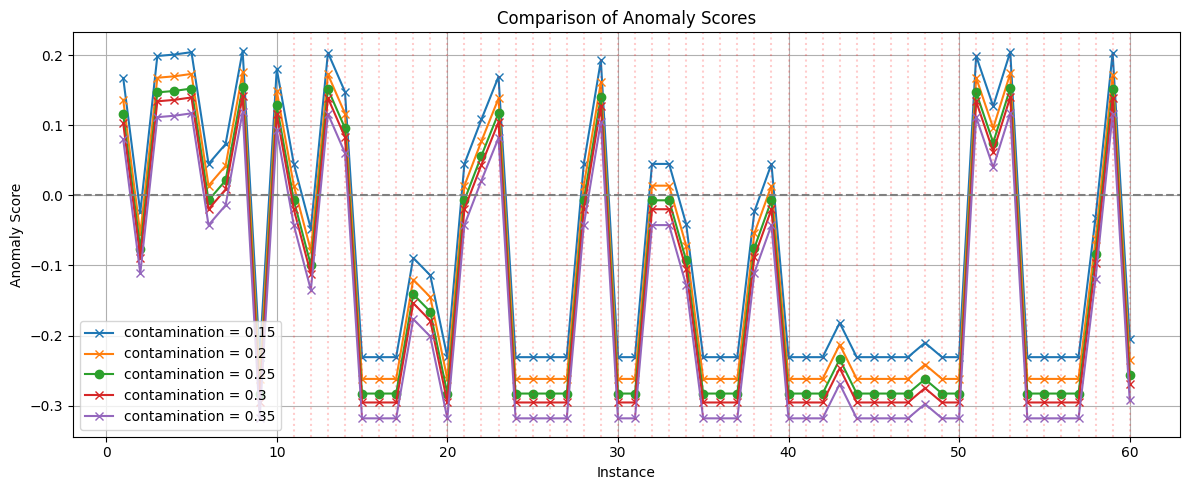

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(instance_summary['instance'], instance_summary['anomaly_score_0.15'], label='contamination = 0.15', marker='x')
plt.plot(instance_summary['instance'], instance_summary['anomaly_score_0.2'], label='contamination = 0.2', marker='x')
plt.plot(instance_summary['instance'], instance_summary['anomaly_score_0.25'], label='contamination = 0.25', marker='o')
plt.plot(instance_summary['instance'], instance_summary['anomaly_score_0.3'], label='contamination = 0.3', marker='x')
plt.plot(instance_summary['instance'], instance_summary['anomaly_score_0.35'], label='contamination = 0.35', marker='x')
plt.axhline(0, color='gray', linestyle='--')

for attack_instance in range(11, 61):
    plt.axvline(x=attack_instance, color='red', linestyle=':', alpha=0.2)

plt.xlabel('Instance')
plt.ylabel('Anomaly Score')
plt.title('Comparison of Anomaly Scores')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [23]:
# Create ground truth column
instance_summary['label'] = (instance_summary['instance'] > 10).astype(int)  # 0 = normal, 1 = attack

In [28]:
from sklearn.metrics import classification_report, confusion_matrix
y_true = instance_summary['label']

# For contamination = 0.15
y_pred_015 = (instance_summary['anomaly_0.15'] == -1).astype(int)
print("=== Contamination 0.15 ===")
print(confusion_matrix(y_true, y_pred_015))
print(classification_report(y_true, y_pred_015))

# For contamination = 0.2
y_pred_02 = (instance_summary['anomaly_0.2'] == -1).astype(int)
print("=== Contamination 0.2 ===")
print(confusion_matrix(y_true, y_pred_02))
print(classification_report(y_true, y_pred_02))

# For contamination = 0.25
y_true = instance_summary['label']
y_pred_025 = (instance_summary['anomaly_0.25'] == -1).astype(int)
print("=== Contamination 0.25 ===")
print(confusion_matrix(y_true, y_pred_025))
print(classification_report(y_true, y_pred_025))

# For contamination = 0.3
y_true = instance_summary['label']
y_pred_03 = (instance_summary['anomaly_0.3'] == -1).astype(int)
print("=== Contamination 0.3 ===")
print(confusion_matrix(y_true, y_pred_03))
print(classification_report(y_true, y_pred_03))

# For contamination = 0.3
y_true = instance_summary['label']
y_pred_035 = (instance_summary['anomaly_0.35'] == -1).astype(int)
print("=== Contamination 0.35 ===")
print(confusion_matrix(y_true, y_pred_035))
print(classification_report(y_true, y_pred_035))

=== Contamination 0.15 ===
[[ 8  2]
 [15 35]]
              precision    recall  f1-score   support

           0       0.35      0.80      0.48        10
           1       0.95      0.70      0.80        50

    accuracy                           0.72        60
   macro avg       0.65      0.75      0.64        60
weighted avg       0.85      0.72      0.75        60

=== Contamination 0.2 ===
[[ 8  2]
 [15 35]]
              precision    recall  f1-score   support

           0       0.35      0.80      0.48        10
           1       0.95      0.70      0.80        50

    accuracy                           0.72        60
   macro avg       0.65      0.75      0.64        60
weighted avg       0.85      0.72      0.75        60

=== Contamination 0.25 ===
[[ 7  3]
 [ 9 41]]
              precision    recall  f1-score   support

           0       0.44      0.70      0.54        10
           1       0.93      0.82      0.87        50

    accuracy                           0.80  

Precision (how many flagged as anomalies are truly attacks)

Recall (how many true attacks were detected)

F1 score (balance)

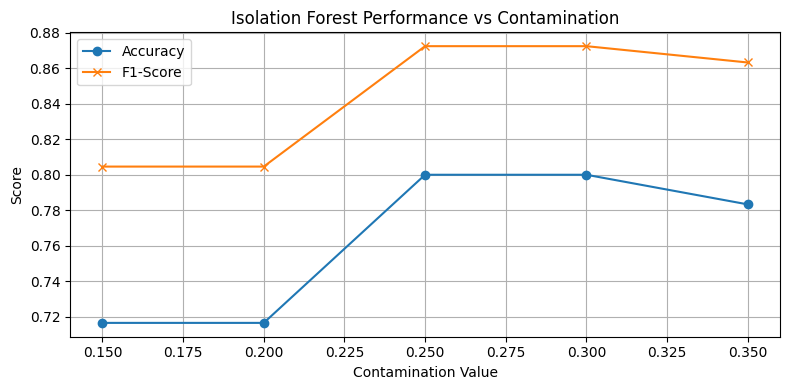

In [32]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score

# Example contamination values and their corresponding F1-scores or accuracy
contamination_vals = [0.15, 0.2, 0.25, 0.3, 0.35]
f1_scores = []
accuracy_vals = []

for cont in contamination_vals:
    y_pred = (instance_summary[f'anomaly_{cont}'] == -1).astype(int)
    f1 = f1_score(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    f1_scores.append(f1)
    accuracy_vals.append(acc)

plt.figure(figsize=(8, 4))
plt.plot(contamination_vals, accuracy_vals, marker='o', label='Accuracy')
plt.plot(contamination_vals, f1_scores, marker='x', label='F1-Score')
plt.title('Isolation Forest Performance vs Contamination')
plt.xlabel('Contamination Value')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**With this empirical study, contamination = 0.25 is chosen as it is an optimal value based on F1-score on the evaluation set**

In [30]:
summary = pd.DataFrame({
    'Instance': instance_summary['instance'],
    'Label': instance_summary['label'],
    'Score_0.25': instance_summary['anomaly_score_0.25'],
    'Anomaly_0.25': y_pred_025,
})
display(summary.head(20))

,Instance,Label,Score_0.25,Anomaly_0.25
0,1,0,0.115396,0
1,2,0,-0.076033,1
2,3,0,0.146823,0
3,4,0,0.148887,0
4,5,0,0.152311,0
5,6,0,-0.007075,1
6,7,0,0.021224,0
7,8,0,0.154344,0
8,9,0,-0.282645,1
9,10,0,0.128183,0


In [35]:
display(instance_summary[['instance', 'write_anomaly_count', 'write_anomaly_ratio', 'write_ops_count', 'write_ops_ratio', 'total_packets', 'anomaly_score_0.25', 'label']])


,instance,write_anomaly_count,write_anomaly_ratio,write_ops_count,write_ops_ratio,total_packets,anomaly_score_0.25,label
0,1,0,0.000000,584,0.234256,2493,0.115396,0
1,2,0,0.000000,514,0.233424,2202,-0.076033,0
2,3,0,0.000000,583,0.234231,2489,0.146823,0
3,4,0,0.000000,572,0.234234,2442,0.148887,0
4,5,0,0.000000,540,0.234070,2307,0.152311,0
5,6,0,0.000000,590,0.234406,2517,-0.007075,0
6,7,0,0.000000,569,0.233868,2433,0.021224,0
7,8,0,0.000000,584,0.234068,2495,0.154344,0
8,9,0,0.000000,576,0.230124,2503,-0.282645,0
9,10,0,0.000000,576,0.234051,2461,0.128183,0


In [36]:
instance_summary.to_csv("instance_anomaly_summary.csv", index=False)

In [37]:
from google.colab import files
files.download("instance_anomaly_summary.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [38]:
import pickle

# Save the trained Isolation Forest model
with open('iso_forest_025.pkl', 'wb') as f:
    pickle.dump(iso_025, f)

print("Model saved as iso_forest_025.pkl")

Model saved as iso_forest_025.pkl


In [40]:
from google.colab import files
files.download("iso_forest_025.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>